# 18 - Continuous EKF/1RC Correction vs Consistency Frontier

## Research question

Does a classical recursive observer beat calibrated Hard-Coulomb after delta-path correction?

## Artifact paths loaded

- `results/v5/ekf_ecm/recursive_vs_ekf_comparison.csv`
- `results/v5/ekf_ecm/continuous_ekf_results.json`
- `results/v5/delta_calibration/eta_gamma_sweep.csv`
- `results/v5/figures/recursive_vs_ekf_temperature_breakdown.png`
- `results/v5/figures/ekf_voltage_residual_case_study.png`

All cells are analysis-only. No heavy training is run.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, Image
except Exception:
    def display(x): print(x)
    def Markdown(x): return x
    def Image(filename=None, **kwargs): return f"Image({filename})"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
COLORS = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#0072B2", "#56B4E9", "#8C8C8C"]
OUR_COLOR = "#E76F51"
BASELINE_COLOR = "#B0BEC5"

def find_repo_root():
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "results" / "v5").exists() and (p / "reports" / "v5_campaign").exists():
            return p
    raise RuntimeError("Could not find repository root containing results/v5 and reports/v5_campaign")

ROOT = find_repo_root()
RESULTS = ROOT / "results" / "v5"
REPORTS = ROOT / "reports" / "v5_campaign"
FIGS = RESULTS / "figures"
missing_artifacts = []

def rel(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT)).replace("\\", "/")
    except Exception:
        return str(path).replace("\\", "/")

def artifact(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if not p.exists():
        missing_artifacts.append(rel(p))
    return p

def read_csv_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return pd.DataFrame()
    return pd.read_csv(p)

def read_json_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return {}
    with p.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def show_artifact_status(paths):
    rows = []
    for item in paths:
        p = ROOT / item
        rows.append({"artifact": item, "exists": p.exists(), "bytes": p.stat().st_size if p.exists() else None})
        if not p.exists():
            missing_artifacts.append(item)
    display(pd.DataFrame(rows))

def show_missing():
    unique = sorted(set(missing_artifacts))
    if unique:
        display(Markdown("### Missing artifacts recorded by this notebook"))
        display(pd.DataFrame({"missing_artifact": unique}))
    else:
        display(Markdown("### Missing artifacts recorded by this notebook: none"))

def maybe_display_png(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        missing_artifacts.append(rel(p))
        display(Markdown(f"Existing figure not found: `{rel(p)}`"))

print("Repository root:", ROOT)


Repository root: D:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC


In [2]:
ARTIFACTS = [
    'results/v5/ekf_ecm/recursive_vs_ekf_comparison.csv',
    'results/v5/ekf_ecm/continuous_ekf_results.json',
    'results/v5/delta_calibration/eta_gamma_sweep.csv',
    'results/v5/figures/recursive_vs_ekf_temperature_breakdown.png',
    'results/v5/figures/ekf_voltage_residual_case_study.png',
]
show_artifact_status(ARTIFACTS)

ekf = read_csv_safe("results/v5/ekf_ecm/recursive_vs_ekf_comparison.csv")
ekf_json = read_json_safe("results/v5/ekf_ecm/continuous_ekf_results.json")
eta = read_csv_safe("results/v5/delta_calibration/eta_gamma_sweep.csv")


,artifact,exists,bytes
0,results/v5/ekf_ecm/recursive_vs_ekf_comparison...,True,966
1,results/v5/ekf_ecm/continuous_ekf_results.json,True,225777
2,results/v5/delta_calibration/eta_gamma_sweep.csv,True,2751
3,results/v5/figures/recursive_vs_ekf_temperatur...,True,37807
4,results/v5/figures/ekf_voltage_residual_case_s...,True,113461


In [3]:
if not ekf.empty:
    display(ekf.sort_values("rmse_pct").round(4))
    best = ekf[ekf["model"].str.contains("EKF", na=False)].sort_values("rmse_pct").head(1)
    if not best.empty:
        r = best.iloc[0]
        display(Markdown(f"**Best EKF:** `{r['model']}` with RMSE `{r['rmse_pct']:.2f}%`, -20 C RMSE `{r['rmse_n20']:.2f}%`, PVR `{r['pvr_disch_eps0']:.2f}%`."))


,model,mae_pct,maxe_40,maxe_n10,maxe_n20,maxe_pct,pvr_disch_eps0,rmse_40,rmse_n10,rmse_n20,rmse_pct
8,EKF_1RC_cont[R=0.01],5.3305,17.5761,21.1546,15.3545,21.1546,5.4755,8.2472,6.2635,5.7709,6.8485
7,EKF_Rint_cont[R=0.01],5.0816,15.6816,24.0407,26.4677,26.4677,4.9444,7.0237,7.0807,8.0919,7.3647
0,HC_windowed,8.3102,13.9331,34.0750,46.1873,46.1873,0.0000,4.2214,9.6602,16.7544,11.0486
2,HC_hybrid_gate,8.9013,15.0180,29.6282,22.4879,29.6282,0.0000,5.3887,14.2859,11.1109,11.1470
1,HC_carried,9.8631,18.6152,29.6282,22.4879,29.6282,0.0000,8.5837,14.2859,11.1109,11.7799
5,EKF_Rint_cont[R=0.0009],17.2259,80.3196,49.5905,55.4619,80.3196,23.8356,25.2384,16.0763,27.1825,22.7623
6,EKF_1RC_cont[R=0.0009],21.4494,80.3116,50.1904,55.5800,80.3116,22.0908,29.3301,21.1993,32.4044,27.4549
3,EKF_Rint_cont[R=0.0001],29.1204,86.7036,73.8037,64.1807,86.7036,39.6150,39.7894,35.2524,35.9334,36.9755
4,EKF_1RC_cont[R=0.0001],31.0467,85.6258,77.8349,64.1807,85.6258,33.6695,39.6158,40.7990,36.0612,39.1161


**Best EKF:** `EKF_1RC_cont[R=0.01]` with RMSE `6.85%`, -20 C RMSE `5.77%`, PVR `5.48%`.

In [4]:
frontier_rows = []
if not eta.empty:
    calibrated = eta[(eta["mode"]=="inference_sweep") & (eta["gamma_mode"]=="nominal") & np.isclose(eta["eta"], 2.0)]
    if not calibrated.empty:
        r = calibrated.iloc[0]
        frontier_rows.append({"model": "Calibrated recursive HC eta=2.0", "rmse_pct": r["rec_rmse_pct"], "rmse_n20": r["rec_rmse_n20"], "maxe_pct": r["rec_maxe_pct"], "pvr_disch_eps0": 0.0, "correction_mode": "Coulomb-consistent carried recursion"})
if not ekf.empty:
    for _, r in ekf[ekf["model"].str.contains("EKF", na=False)].iterrows():
        frontier_rows.append({"model": r["model"], "rmse_pct": r["rmse_pct"], "rmse_n20": r["rmse_n20"], "maxe_pct": r["maxe_pct"], "pvr_disch_eps0": r["pvr_disch_eps0"], "correction_mode": "Voltage-feedback EKF"})
frontier = pd.DataFrame(frontier_rows)
if not frontier.empty:
    display(frontier.sort_values("rmse_pct").round(4))


,model,rmse_pct,rmse_n20,maxe_pct,pvr_disch_eps0,correction_mode
0,Calibrated recursive HC eta=2.0,4.4318,3.5936,15.8296,0.0000,Coulomb-consistent carried recursion
6,EKF_1RC_cont[R=0.01],6.8485,5.7709,21.1546,5.4755,Voltage-feedback EKF
5,EKF_Rint_cont[R=0.01],7.3647,8.0919,26.4677,4.9444,Voltage-feedback EKF
3,EKF_Rint_cont[R=0.0009],22.7623,27.1825,80.3196,23.8356,Voltage-feedback EKF
4,EKF_1RC_cont[R=0.0009],27.4549,32.4044,80.3116,22.0908,Voltage-feedback EKF
1,EKF_Rint_cont[R=0.0001],36.9755,35.9334,86.7036,39.6150,Voltage-feedback EKF
2,EKF_1RC_cont[R=0.0001],39.1161,36.0612,85.6258,33.6695,Voltage-feedback EKF


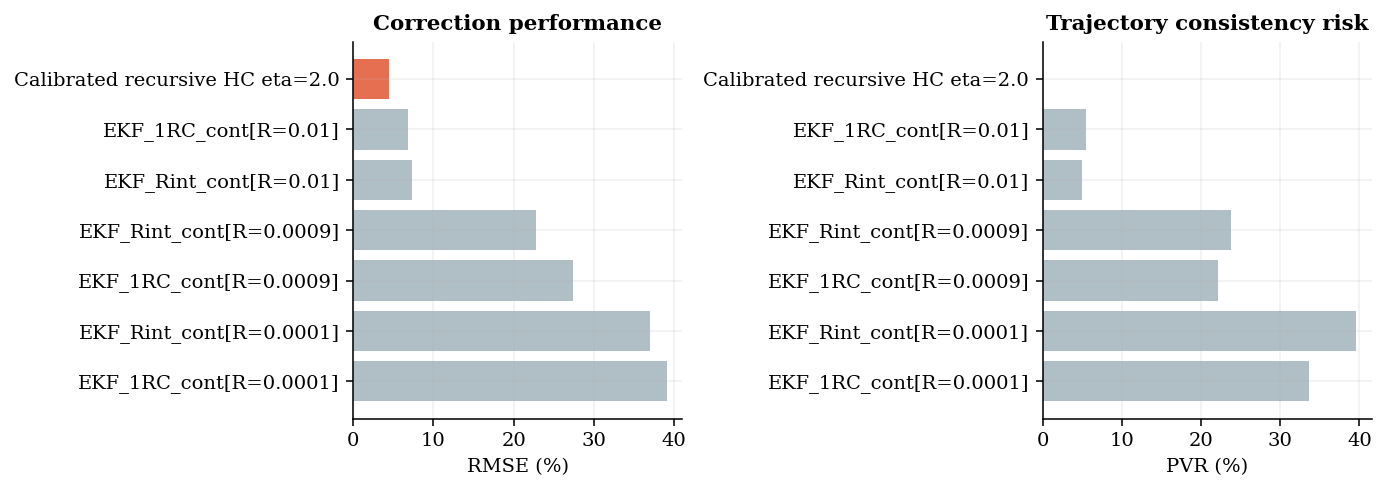

**EKF R-sensitivity:** RMSE range `6.85` to `39.12%`; PVR range `4.94` to `39.62%`.

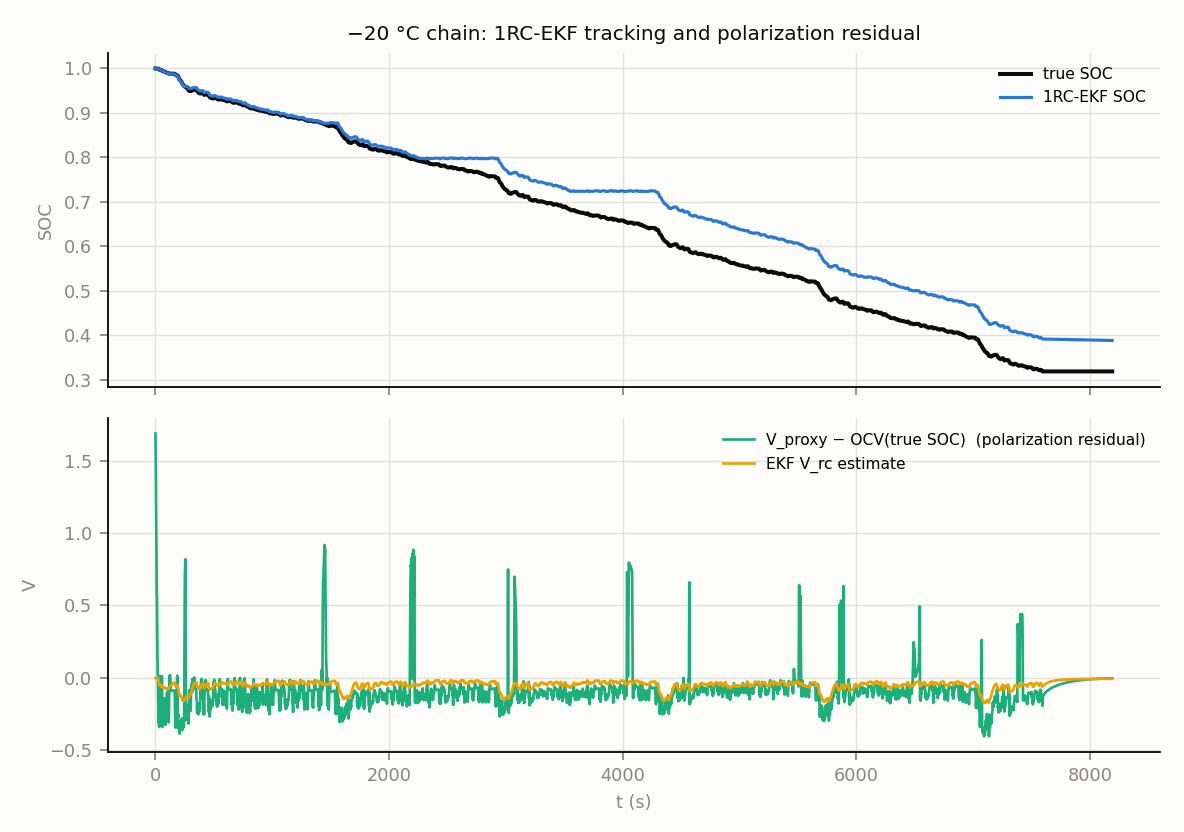

In [5]:
if "frontier" in globals() and not frontier.empty:
    top = frontier.sort_values("rmse_pct")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    colors = [OUR_COLOR if "Calibrated" in m else BASELINE_COLOR for m in top["model"]]
    axes[0].barh(top["model"], top["rmse_pct"], color=colors); axes[0].set_xlabel("RMSE (%)"); axes[0].set_title("Correction performance"); axes[0].invert_yaxis()
    axes[1].barh(top["model"], top["pvr_disch_eps0"], color=colors); axes[1].set_xlabel("PVR (%)"); axes[1].set_title("Trajectory consistency risk"); axes[1].invert_yaxis()
    plt.tight_layout(); plt.show()
if not ekf.empty:
    ekf_only = ekf[ekf["model"].str.contains("EKF", na=False)]
    display(Markdown(f"**EKF R-sensitivity:** RMSE range `{ekf_only['rmse_pct'].min():.2f}` to `{ekf_only['rmse_pct'].max():.2f}%`; PVR range `{ekf_only['pvr_disch_eps0'].min():.2f}` to `{ekf_only['pvr_disch_eps0'].max():.2f}%`."))
maybe_display_png("results/v5/figures/ekf_voltage_residual_case_study.png")


## Interpretation

EKF corrects through voltage feedback, but the tested 1RC/Rint observers are sensitive to measurement-noise assumptions and can violate trajectory sign consistency. Calibrated HC keeps PVR at zero and beats the best EKF row in this setup.

## Reviewer-risk note

Do not claim all EKFs are inferior. This is an assumed-parameter EKF/ECM comparison on this dataset, not a fully identified industrial observer.

## Final conclusion

EKF corrects with voltage feedback but violates trajectory consistency; calibrated HC preserves consistency and outperforms EKF in this setup.


In [6]:
show_missing()


### Missing artifacts recorded by this notebook: none

## Publication asset export (PUBLICATION_ASSET_EXPORT_V1)

This cell exports manuscript-ready figures/tables from existing v5 CSV/JSON artifacts only. It does not run training or alter experiment results.


In [ ]:
# PUBLICATION_ASSET_EXPORT_V1
from pathlib import Path
import sys
EXPORT_DIR = Path('notebooks/ablation_studies_v5_final').resolve()
if str(EXPORT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPORT_DIR))
from publication_asset_exports import export_for_notebook
validation = export_for_notebook('18')
print('publication assets refreshed:', validation['png_present'], 'figures and', validation['csv_present'], 'tables')
